#### Local feature detectors and descriptors
They find distinctive points in an image, like corners or edges of brushstrokes and describe their appearance in a way that’s invariant to scale, rotation, and sometimes illumination. They capture style-level and texture-level similarity.

- SIFT (Scale-Invariant Feature Transform) - uses gradient information
- FAST (Features from Accelerated Segment Test) - uses intensity differences
- ORB (Oriented FAST and Rotated BRIEF) - uses binary patterns or intensity comparisons

Using this paper in google doc. ORB best paintings

SIFT: Computes gradient-based descriptors around keypoints, invariant to scale and rotation.
SURF: Detects corners by comparing pixel intensity patterns; you combine it with SIFT to describe them.
ORB: Combines FAST for detection and BRIEF (binary intensity comparisons) for description.

| Use Case                         | Why SIFT/SURF/ORB Help                                                                                                                                     |
| -------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Style similarity**             | Two paintings from the same artist or movement (e.g., Impressionism) will have similar texture and brushstroke patterns, which local features can capture. |
| **Brushstroke analysis**         | Keypoints often align along textured strokes, providing a “signature” for how an artist paints.                                                            |
| **Pattern or motif repetition**  | They can identify recurring patterns (e.g., similar sky texture, tree forms).                                                                              |
| **Visual matching / clustering** | You can compute feature vectors (mean of descriptors, or Bag of Visual Words representation) and compare them using cosine or Euclidean distance.          |


Parameters used from papers in google doc (most are default)

In [ ]:
# all necessary imports are listed below
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern

In [ ]:
dataset_path = r'C:\Users\danie\Desktop\_\Daniela_Curmi\University\Final_Year_Project\Code_Implementation\Website\paintings'

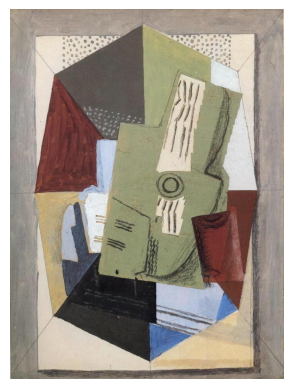

In [8]:
# Test Image
image_path = r'C:\Users\danie\Desktop\_\Daniela_Curmi\University\Final_Year_Project\Code_Implementation\Website\paintings\Synthetic_Cubism\georges-braque_guitar-and-sheet-music-on-table-1918.jpg'
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis("off")
plt.show()

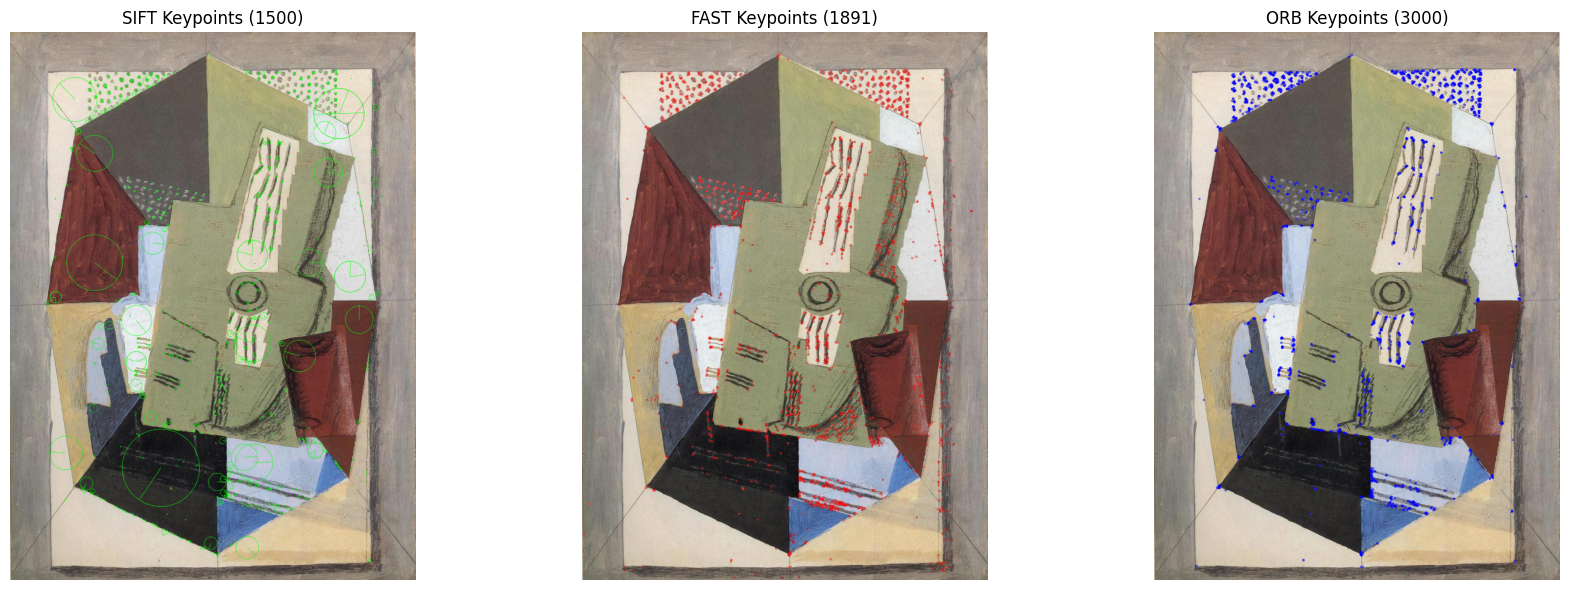

In [ ]:
# feature detection methods
def detect_sift(gray):
    sift = cv2.SIFT_create(nfeatures=1500, contrastThreshold=0.04, edgeThreshold=10, sigma=1.6)
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    return keypoints, descriptors

def detect_fast(gray):
    fast = cv2.FastFeatureDetector_create(threshold=37, nonmaxSuppression=True)
    keypoints = fast.detect(gray, None)
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.compute(gray, keypoints)
    return keypoints, descriptors
    
def detect_orb(gray):
    orb = cv2.ORB_create(nfeatures=3000) 
    keypoints, descriptors = orb.detectAndCompute(gray, None)
    return keypoints, descriptors

def visualize_keypoints(img):
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect keypoints for each method
    keypoints_sift, _ = detect_sift(gray)
    keypoints_fast, _ = detect_fast(gray)
    keypoints_orb, _ = detect_orb(gray)

    # Draw keypoints on copies of the image
    img_sift = cv2.drawKeypoints(img, keypoints_sift, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    img_fast = cv2.drawKeypoints(img, keypoints_fast, None, color=(255, 0, 0))
    img_orb  = cv2.drawKeypoints(img, keypoints_orb,  None, color=(0, 0, 255))

    # Display side by side
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.imshow(img_sift)
    plt.title(f"SIFT Keypoints ({len(keypoints_sift)})")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(img_fast)
    plt.title(f"FAST Keypoints ({len(keypoints_fast)})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img_orb)
    plt.title(f"ORB Keypoints ({len(keypoints_orb)})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

visualize_keypoints(image_rgb)